# **PicassoPy Workshop --> Test case: cpv 2024-08-21**
---


- Folder for data `test_case_data` -> download separately
- Folder for configs `test_case_config`

The autoreload below is needed to directly pull in changes in the picassopy source code

In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import os, sys
import argparse
import datetime
import logging
from pathlib import Path
import numpy as np

sys.path.append('../')
import ppcpy
import ppcpy.io.loadConfigs as loadConfigs
import ppcpy.io.readPollyRawData as readPollyRawData
import ppcpy.interface.picassoProc as picassoProc
import ppcpy.misc.helper as helper
import ppcpy.misc.startscreen as startscreen
from ppcpy.io.write2nc import write_channelwise_2_nc_file, write2nc_file, write_profile2nc_file

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab20.colors)

## Defining Script Inputs

- The parameters `args.device`, `args.timestamp`, `args.picasso_config_file`, `args.level0_file_to_process`, need to be manually specified per case.
- The parameter `DATABASE_PATH` is the path to the database used for storing the retrieved calibration constants

In [3]:
## For purpose of the notebook mimic the argparse interface
from types import SimpleNamespace
args = SimpleNamespace()

## The used device and time of mesurment
args.device = 'pollyxt_cpv'
args.timestamp = '20240821'
dt = datetime.datetime.strptime(args.timestamp, "%Y%m%d")

## The used config file
args.picasso_config_file = "test_case_config/pollynet_processing_chain_config_test.json"

## The data file to use
args.level0_file_to_process = f"test_case_data/{dt:%Y_%m_%d_%a}_CPV_00_00_01.nc"


## Database path
DATABASE_PATH = "PicassoPyDatabase.db" # I should test if it works to read this directly from the config files.

In [4]:
startscreen.startscreen()

      ____  _                            ____           ___ ____ 
     / __ \(_)________ _______________  / __ \__  __   <  // __ \
    / /_/ / / ___/ __ `/ ___/ ___/ __ \/ /_/ / / / /   / // / / /
   / ____/ / /__/ /_/ (__  |__  ) /_/ / ____/ /_/ /   / // /_/ / 
  /_/   /_/\___/\__,_/____/____/\____/_/    \__, /   /_(_)____/  
                                           /____/                


## Load Data and Config-files

Loads data and information from the config files into the following three dictionaries:
- `picasso_config_dict`: Paths and other information stored in the picasso config file
- `polly_config_dict`: Configuration variables from polly config and polly default files
- `rawdata_dict`: Measurement data and information extracted from the level0 file

In [5]:
## Path to dafault Picasso config file
picasso_default_config_file = Path(
    helper.detect_path_type(Path.cwd().parent), 'ppcpy', 'config', 'pollynet_processing_chain_config.json')

## Load Picasso config file
picasso_config_dict = loadConfigs.loadPicassoConfig(args.picasso_config_file, picasso_default_config_file)

## load polly config file
polly_config_array = loadConfigs.readPollyNetConfigLinkTable(picasso_config_dict['pollynet_config_link_file'], timestamp=args.timestamp, device=args.device)
polly_config_dict = loadConfigs.getPollyConfigfromArray(
    polly_config_array, picasso_config_dict
)

## Load level0-data file
rawfile_fullname = args.level0_file_to_process
rawfile = helper.detect_path_type(rawfile_fullname)
rawdata_dict = readPollyRawData.readPollyRawData(rawfile)

2026-05-20 17:39:55,041 - INFO - picasso_default_config_file: /mnt/c/Users/radenz/dev/PicassoPy/PicassoPy/ppcpy/config/pollynet_processing_chain_config.json
2026-05-20 17:39:55,058 - INFO - picasso_config_file: test_case_config/pollynet_processing_chain_config_test.json
2026-05-20 17:39:55,073 - INFO - pollynet_config_link_file: test_case_config/pollynet_processing_chain_config_links.xlsx
2026-05-20 17:39:59,161 - INFO - polly_default_config_file: /mnt/c/Users/radenz/dev/PicassoPy/PicassoPy/ppcpy/config/polly_global_config.json
2026-05-20 17:39:59,172 - INFO - polly_config_file: test_case_config/pollyxt_cpv_config_20230927.json
2026-05-20 17:39:59,181 - INFO - keys default/template file, but not in specific file {'refH_FR_532', 'yLim_cloudinfo', 'maxCloudSearchHeight_NR', 'zLim_FR_RCS_607', 'polCaliEtaStd1064', 'ice_thres_vol_depol', 'cloud_thres_par_beta_1064', 'zLim_FR_RCS_407', 'molDepol1064', 'droplet_thres_par_depol', 'xLim_Profi_LR', 'isParallel', 'yLim_beta_532_Poliphon', 'minSN

## Initialize PicassoProc object

PicassoProc is the main object in the PicassoPy, and is responsible for running all processes included and storing the data.

In [17]:
time_period = [0, 500]
rawdata_dict['raw_signal']['var_data'] = rawdata_dict['raw_signal']['var_data'][slice(*time_period),...]
rawdata_dict['measurement_shots']['var_data'] = rawdata_dict['measurement_shots']['var_data'][slice(*time_period),...]
rawdata_dict['measurement_time']['var_data'] = rawdata_dict['measurement_time']['var_data'][slice(*time_period),...]
rawdata_dict['depol_cal_angle']['var_data'] = rawdata_dict['depol_cal_angle']['var_data'][slice(*time_period),...]
rawdata_dict['location_coordinates']['var_data'] = rawdata_dict['location_coordinates']['var_data'][slice(*time_period),...]

In [18]:
## Initialize PicassoProc
data_cube = picassoProc.PicassoProc(rawdata_dict, polly_config_dict, picasso_config_dict)

In [19]:
## reset date if date in filename differs date within nc-file 
data_cube.reset_date_infile()

## checking for correct mshots
data_cube.check_for_correct_mshots()

## setting channelTags
data_cube.setChannelTags()

## check for correct date in nc-file
data_cube.reset_date_infile()

2026-05-20 18:14:18,554 - INFO - date consistency-check... 
2026-05-20 18:14:18,559 - INFO - ... date in nc-file equals date of filename
2026-05-20 18:14:18,573 - INFO - ChannelLabels: ['FR-total-355 nm', 'FR-cross-355 nm', 'FR-387 nm', 'FR-407 nm', 'FR-total-532 nm', 'FR-cross-532 nm', 'FR-607 nm', 'FR-total-1064 nm', 'NR-total-532 nm', 'NR-607 nm', 'NR-total-355 nm', 'NR-387 nm', 'DFOV', '1058', '1064s']
2026-05-20 18:14:18,577 - INFO - date consistency-check... 
2026-05-20 18:14:18,579 - INFO - ... date in nc-file equals date of filename


## Preprocessing & Saturation Detection

The preprocessing includes the following processes:
- Deadtime correction
- Background correction
- SNR claculations
- Flagging of data
- Range correction

In [20]:
## Perform preprocessing, this includes Dead-time correction, Background correction, and Range correction
data_cube.preprocessing(collect_debug=True)

2026-05-20 18:14:24,308 - INFO - starting data preprocessing...
2026-05-20 18:14:24,313 - INFO - ... time conversion
2026-05-20 18:14:24,330 - WARNING - ... mShots not constant min 2993 max 2999
2026-05-20 18:14:24,344 - INFO - ... Deadtime-correction (Mode: 1)


mShots_norm (500, 15) mShots_norm [2995.756 2995.756 2995.756 2995.756 2995.756 2995.756 2995.756 2995.756
 2995.738 2995.738 2995.738 2995.738 2995.738 2995.738 2995.738]


2026-05-20 18:14:47,823 - INFO - ... removing background from signal
2026-05-20 18:15:02,544 - INFO - ... height bin calculations
2026-05-20 18:15:05,396 - INFO - ... mask bins with low SNR
2026-05-20 18:15:20,136 - INFO - ... mask for polarization calibration
2026-05-20 18:15:20,166 - INFO - ... calculate range-corrected Signal


flag 532 FR [False False False False  True False False False False False False False
 False False False]
flag 355 FR [ True False False False False False False False False False False False
 False False False]
flag 607 FR [False False False False False False  True False False False False False
 False False False]
flagNDepCal [False False False False False False False False False False False False
  True  True  True  True  True  True  True  True False]
flagPDepCal [False False  True  True  True  True  True  True  True  True False False
 False False False False False False False False False]
depCalPeriods [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0

2026-05-20 18:15:21,927 - INFO - finished data preprocessing.


(500, 4000, 15)
ranges2d (500, 4000)


In [21]:
## Save high resolution signal-to-noise ratio, background, and range corrected signal
#write_channelwise_2_nc_file(data_cube=data_cube, prod_ls=['SNR', 'BG', 'RCS'])

In [22]:
## Display available channels
data_cube.channel_dict

{0: 'FR-total-355 nm',
 1: 'FR-cross-355 nm',
 2: 'FR-387 nm',
 3: 'FR-407 nm',
 4: 'FR-total-532 nm',
 5: 'FR-cross-532 nm',
 6: 'FR-607 nm',
 7: 'FR-total-1064 nm',
 8: 'NR-total-532 nm',
 9: 'NR-607 nm',
 10: 'NR-total-355 nm',
 11: 'NR-387 nm',
 12: 'DFOV',
 13: '1058',
 14: '1064s'}

In [23]:
## Detect and flag saturated signal
data_cube.SaturationDetect()

2026-05-20 18:15:39,297 - INFO - Saturation detection


## Cloud Screening

Three modes of cloud Screening are currently implemented:

0. No cloud screening. Return cloud free for all timestamps
1. Cloud screen with Maximum Gradiant Signal (MSG) algorithm
2. Cloud screen with Zhao's algorithm

Clouds are screened per timestamp (30s). After the screening the data is splitt up into cloud free segments and aggregated.

In [24]:
## Apply cloud screening
data_cube.cloudScreen()

2026-05-20 18:15:50,048 - INFO - cloud screen mode 1: MSG method.


Starting cloud screen


In [25]:
## Segmentate cloud free groups
data_cube.cloudFreeSeg()

intNProfiles 120 minIntNProfiles 30


In [26]:
## Display cloud free groups
data_cube.clFreeGrps

array([[  0, 113],
       [144, 244]])

### Exclude individual cloudy profiles

In [70]:
# Manually set the the start and stop of the profile including the cloud period
data_cube.clFreeGrps = np.array([[325, 365]])

# If needed modify the data_cube.flagCloudFree and run data_cube.genFlagValPrf()

# then when calling aggregate_profiles the function call has to be modified (see below)

### Plot example: Cloud free groups

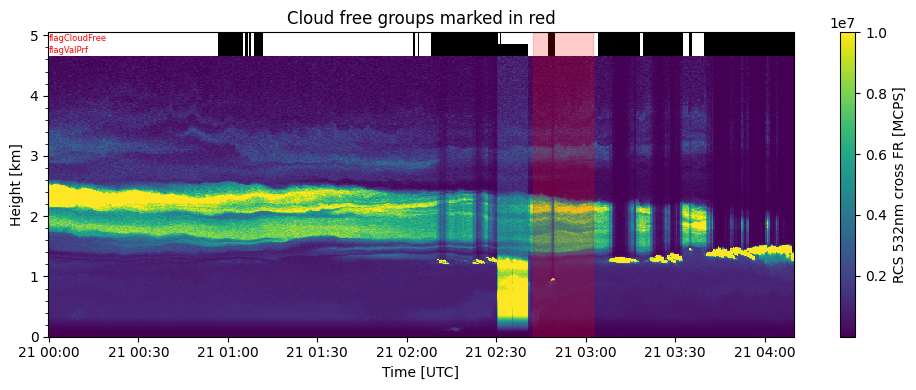

In [71]:
wv, t, tel = 532, 'cross', 'FR'

fig, ax = plt.subplots(figsize=(10, 4))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    np.squeeze(data_cube.retrievals_highres['RCS'][:, :, data_cube.gf(wv, t, tel)]).T,
    shading='nearest',
    vmin=5, vmax=1e7
)

flag1 = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    [4.9,5],
    np.repeat(data_cube.flagCloudFree[:,np.newaxis], 2, axis=1).T,
    shading='nearest', cmap='binary_r'
)
ax.text(data_cube.retrievals_highres["time64"][0], 4.9, "flagCloudFree", fontsize=6, color='red')
flag2 = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    [4.7,4.8],
    np.repeat(data_cube.flagValPrf[:,np.newaxis], 2, axis=1).T,
    shading='nearest', cmap='binary_r'
)
ax.text(data_cube.retrievals_highres["time64"][0], 4.7, "flagValPrf", fontsize=6, color='red')

for cldFreGrp in data_cube.clFreeGrps:
    ax.axvspan(
        data_cube.retrievals_highres["time64"][cldFreGrp[0]],
        data_cube.retrievals_highres["time64"][cldFreGrp[1]],
        color="red", alpha=0.2
    )

cbar = fig.colorbar(pcmesh)
cbar.set_label(f'RCS {wv}nm {t} {tel} [MCPS]')
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator())
ax.set_xlabel('Time [UTC]')
ax.set_ylabel('Height [km]')
ax.set_title('Cloud free groups marked in red')
ax.set_ylim(0, 5.05)
fig.tight_layout()

In [89]:
## Aggregate background, background corrected signal, and range corrected signal
# data_cube.aggregate_profiles()
data_cube.aggregate_profiles(flagVal=True)

(41, 4000, 15)
(36, 4000, 15)
(41, 4000, 15)
(36, 4000, 15)
(41, 15)
(36, 15)


### Plot example: Aggregated profiles

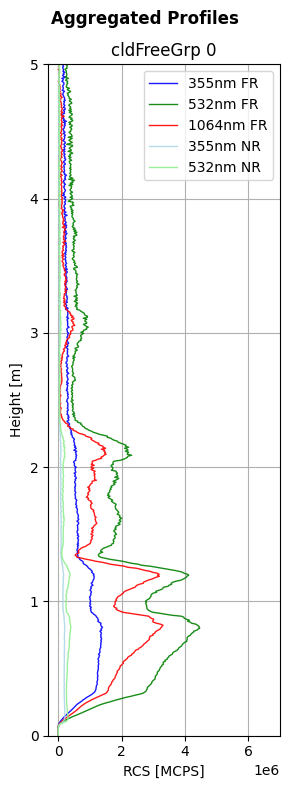

In [90]:
fig, ax = plt.subplots(1, figsize=(3, 8), sharey=True)
ax.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR')
ax.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR')
ax.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(1064, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR')
ax.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm NR')
ax.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm NR')
ax.grid()
ax.set_ylim(0, 5)
ax.set_xlim(right=7e6)
ax.legend(loc='upper right')
ax.set_ylabel('Height [m]')
ax.set_xlabel('RCS [MCPS]')
ax.set_title('cldFreeGrp 0')

fig.suptitle("Aggregated Profiles", fontweight='bold')
fig.tight_layout()
